## Data Exploration

The point of this notebook is to explore stock data from before the testing period, mainly focusing on their performance, autocorrelation and ARCH effects. Some mean models are also fitted to help with exploration.

## Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import ar_select_order

In [2]:
# Find project root (folder that contains .git)
ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent

# Set working directory to root
os.chdir(ROOT)

print("Now working in:", Path.cwd())

Now working in: C:\Users\couch\OneDrive\Assignments\Master Thesis\Repo


In [3]:
from src.config import VAL_END

In [4]:
sns.set_theme(style="whitegrid")

## Data Loading

In [5]:
df = pd.read_parquet("results/processed_data/stock_data.parquet", engine="pyarrow")
df.index = pd.to_datetime(df.index)
df = df[df.index <= VAL_END]
df

,ALR,CDR,CPS,DNP,EBP,JSW,KGH,LPP,LTS,MBK,MDV,OPL,PEO,PGE,PGN,PKN,PKO,PLY,PZU,TPE
Date,,,,,,,,,,,,,,,,,,,,
2014-01-03,-0.009629,-0.006342,-0.001011,NaN,-0.010414,0.009294,-0.003378,0.011834,-0.007074,-0.017298,-0.004692,0.005099,-0.010880,0.001238,-0.021053,-0.014708,-0.015544,NaN,-0.016329,-0.013668
2014-01-07,-0.019666,-0.017503,-0.023013,NaN,-0.034886,-0.023588,-0.021377,-0.030703,-0.030714,-0.028988,-0.017684,-0.008172,-0.029895,-0.009326,-0.047534,-0.009927,-0.015267,NaN,-0.019091,-0.025553
2014-01-08,0.009443,-0.005311,-0.026207,NaN,0.018792,0.002082,0.001296,-0.006255,-0.009915,0.024385,-0.019777,-0.005141,0.031297,-0.007524,-0.008147,-0.002378,0.001303,NaN,0.006554,0.007034
2014-01-09,0.000000,-0.003557,-0.005325,NaN,0.000000,-0.051194,-0.032013,-0.030700,-0.001608,-0.034839,0.011035,0.000000,-0.031297,0.008772,0.020244,-0.014389,-0.010734,NaN,-0.024862,-0.016490
2014-01-10,0.000000,-0.002378,0.014312,NaN,-0.008011,-0.017259,-0.005362,0.000000,-0.002902,0.018718,-0.016822,0.008214,0.022858,-0.018257,-0.028457,0.019139,0.008388,NaN,-0.016298,-0.004762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-19,-0.008316,0.002235,-0.035718,0.015839,-0.010724,-0.009950,0.010417,0.002861,-0.006439,0.011233,0.011215,-0.005450,0.003980,-0.011187,0.009479,0.012261,-0.007685,-0.011856,0.007701,-0.024244
2019-12-20,-0.015428,0.005197,0.014441,0.014185,0.000674,-0.009545,-0.015456,-0.003434,0.028654,-0.004799,-0.009337,-0.022100,-0.005976,-0.006270,-0.007101,-0.014637,-0.006881,0.017145,0.004444,-0.018576
2019-12-23,-0.009943,0.035997,0.002148,-0.004942,0.014706,0.010545,-0.000211,0.003434,0.017945,0.040843,0.007477,-0.015482,0.011423,0.002513,0.007101,0.012290,-0.002593,-0.012980,-0.006426,-0.006270


## Stock Performance

Total return for each year is visualized. If any data is missing for an asset then it's omitted.

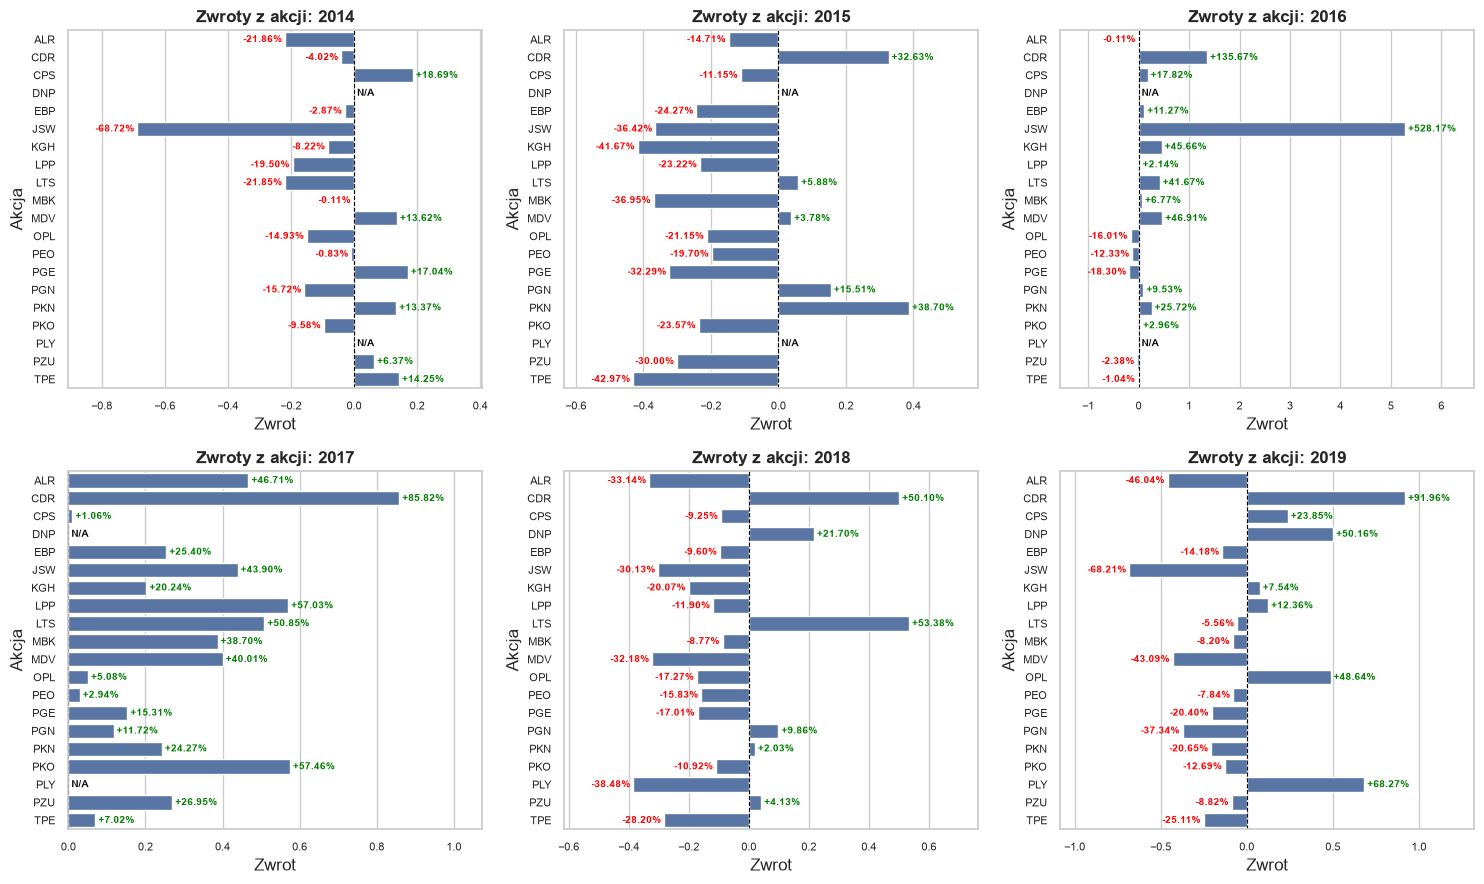

In [6]:
years = df.index.year.unique()
ncols = 3
nrows = (len(years) + ncols - 1) // ncols  # Calculate rows dynamically

# Adjust figure size for a compact layout (15 width, 4.5 height per row)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))

# Flatten axes array for simple indexing regardless of grid dimensions
axes_flat = np.array(axes).flatten()

for i, year in enumerate(years):
    ax = axes_flat[i]

    # Filter out returns for the current year
    df_year = df.loc[str(year)]

    # Identify which assets contain NaNs in the current year
    has_nan = df_year.isna().any()

    # Calculate simple annual returns for valid assets
    valid_returns = np.exp(df_year.dropna(axis=1, how="any").sum()) - 1

    # Reindex so all 20 assets remain present in every subplot
    all_returns = valid_returns.reindex(df.columns)

    # Horizontal bar plot: assign values to x and asset names to y
    sns.barplot(x=all_returns.values, y=all_returns.index, ax=ax)

    # Add dynamically colored text labels for every bar
    for y_idx, val in enumerate(all_returns.values):
        if pd.isna(val):
            ax.text(
                0,
                y_idx,
                " N/A",
                va="center",
                ha="left",
                fontsize=7.5,
                color="black",
                fontweight="bold",
            )
        elif val >= 0:
            ax.text(
                val,
                y_idx,
                f" {val * 100:+.2f}%",
                va="center",
                ha="left",
                fontsize=7.5,
                color="green",
                fontweight="bold",
            )
        else:
            ax.text(
                val,
                y_idx,
                f"{val * 100:.2f}% ",
                va="center",
                ha="right",
                fontsize=7.5,
                color="red",
                fontweight="bold",
            )

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Zwroty z akcji: {year}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Zwrot")
    ax.set_ylabel("Akcja")
    ax.tick_params(axis="both", labelsize=8)

    # Add horizontal padding to prevent outer labels from being cut off
    ax.margins(x=0.25)

# Remove any empty unused subplot slots in the final row
for j in range(len(years), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

## Autocorrelation

Due to the sheer number of assets, this part is going to be restricted to a per-asset Ljung-Box test with 20 lags on the last 2 years in the dataset. This is meant to make it more digestible and interpretable.

In [7]:
# Filter dataset for the last 2 calendar years based on year numbers
latest_year = df.index.year.max()
df_2y = df[df.index.year >= (latest_year - 1)]

# Perform Ljung-Box test with 20 lags per stock
results = {}

for stock in df.columns:
    series = df_2y[stock]

    # Evaluate autocorrelation at lag 20
    lb_res = acorr_ljungbox(series, lags=[20], return_df=True)
    p_val = float(lb_res["lb_pvalue"].iloc[-1])

    # Format to 4 decimal places with comma as decimal separator
    results[stock] = f"{p_val:.4f}".replace(".", ",")

# Build final DataFrame with stock names as index
ljung_box_df = pd.DataFrame.from_dict(results, orient="index", columns=["p-value"])
display(ljung_box_df)

print(ljung_box_df.to_latex(index=True))

,p-value
ALR,"0,1914"
CDR,"0,7937"
CPS,"0,0047"
DNP,"0,3662"
EBP,"0,1270"
JSW,"0,4275"
KGH,"0,6297"
LPP,"0,0035"
LTS,"0,8059"
MBK,"0,8340"


\begin{tabular}{ll}
\toprule
 & p-value \\
\midrule
ALR & 0,1914 \\
CDR & 0,7937 \\
CPS & 0,0047 \\
DNP & 0,3662 \\
EBP & 0,1270 \\
JSW & 0,4275 \\
KGH & 0,6297 \\
LPP & 0,0035 \\
LTS & 0,8059 \\
MBK & 0,8340 \\
MDV & 0,2079 \\
OPL & 0,2874 \\
PEO & 0,7383 \\
PGE & 0,8134 \\
PGN & 0,1379 \\
PKN & 0,5083 \\
PKO & 0,6069 \\
PLY & 0,7231 \\
PZU & 0,4913 \\
TPE & 0,0834 \\
\bottomrule
\end{tabular}



## AR Models

AR models are built for each of these series using HQIC to pick lags and see if significant autocorrelation was removed. ARCH effects and vector correlation on model residuals are also tested.

In [8]:
results = {}
residuals_dict = {}

for stock in df.columns:
    series = df_2y[stock].reset_index(drop=True)

    # Fit optimal AR model order using Hannan-Quinn Information Criterion (HQIC)
    selector = ar_select_order(series, maxlag=20, ic="hqic", trend="c")
    fitted_model = selector.model.fit()

    # Extract selected lag p (0 if no lags chosen)
    ar_lags = selector.ar_lags
    p_lag = max(ar_lags) if ar_lags is not None and len(ar_lags) > 0 else 0

    # Extract residuals and squared residuals
    resids = fitted_model.resid
    residuals_dict[stock] = resids
    sq_resids = resids**2

    # Perform Ljung-Box test with 20 lags on residuals
    lb_res_p = float(acorr_ljungbox(resids, lags=[20], model_df=p_lag, return_df=True)["lb_pvalue"].iloc[-1])

    # Perform Ljung-Box test with 20 lags on squared residuals
    lb_sq_p = float(acorr_ljungbox(sq_resids, lags=[20], return_df=True)["lb_pvalue"].iloc[-1])

    results[stock] = {
        "p": p_lag,
        "Ljung-Box (reszty)": f"{lb_res_p:.4f}".replace(".", ","),
        "Ljung-Box (kwadraty reszt)": f"{lb_sq_p:.4f}".replace(".", ","),
    }

# Build final DataFrame indexed by stock name
ar_diagnostics_df = pd.DataFrame.from_dict(results, orient="index")
display(ar_diagnostics_df)

print(ar_diagnostics_df.to_latex(index=True))

,p,Ljung-Box (reszty),Ljung-Box (kwadraty reszt)
ALR,0,"0,1914","0,0721"
CDR,0,"0,7937","0,0000"
CPS,2,"0,4160","0,4658"
DNP,0,"0,3662","0,2256"
EBP,2,"0,5051","0,3499"
JSW,0,"0,4275","0,0000"
KGH,0,"0,6297","0,1532"
LPP,2,"0,0347","0,5711"
LTS,0,"0,8059","0,1834"
MBK,1,"0,9666","0,0366"


\begin{tabular}{lrll}
\toprule
 & p & Ljung-Box (reszty) & Ljung-Box (kwadraty reszt) \\
\midrule
ALR & 0 & 0,1914 & 0,0721 \\
CDR & 0 & 0,7937 & 0,0000 \\
CPS & 2 & 0,4160 & 0,4658 \\
DNP & 0 & 0,3662 & 0,2256 \\
EBP & 2 & 0,5051 & 0,3499 \\
JSW & 0 & 0,4275 & 0,0000 \\
KGH & 0 & 0,6297 & 0,1532 \\
LPP & 2 & 0,0347 & 0,5711 \\
LTS & 0 & 0,8059 & 0,1834 \\
MBK & 1 & 0,9666 & 0,0366 \\
MDV & 2 & 0,4326 & 0,8543 \\
OPL & 0 & 0,2874 & 0,0000 \\
PEO & 0 & 0,7383 & 0,8598 \\
PGE & 0 & 0,8134 & 0,9415 \\
PGN & 2 & 0,2688 & 0,1047 \\
PKN & 0 & 0,5083 & 0,7784 \\
PKO & 0 & 0,6069 & 0,1020 \\
PLY & 0 & 0,7231 & 0,5209 \\
PZU & 0 & 0,4913 & 0,6051 \\
TPE & 0 & 0,0834 & 0,0818 \\
\bottomrule
\end{tabular}



In [9]:
# Align AR residual series into a single DataFrame
residuals_df = pd.DataFrame(residuals_dict).dropna()

# Fit a 0-lag VAR on the residual matrix to access multivariate diagnostics
var_model = VAR(residuals_df)
var_res = var_model.fit(maxlags=0)

# Perform Multivariate Ljung-Box test
whiteness_test = var_res.test_whiteness(nlags=5, adjusted=True)

# Format into summary DataFrame
mv_lb_df = pd.DataFrame(
    [
        {
            "Statystyka": f"{whiteness_test.test_statistic:.4f}".replace(".", ","),
            "Opóźnienia": 5,
            "Stopnie swobody": whiteness_test.df,
            "p-value": f"{whiteness_test.pvalue:.4f}".replace(".", ","),
        }
    ],
    index=["Test wektorowej autokorelacji"],
)
display(mv_lb_df)

print(mv_lb_df.to_latex(index=True))

,Statystyka,Opóźnienia,Stopnie swobody,p-value
Test wektorowej autokorelacji,"2179,4793",5,2000,"0,0028"


\begin{tabular}{llrrl}
\toprule
 & Statystyka & Opóźnienia & Stopnie swobody & p-value \\
\midrule
Test wektorowej autokorelacji & 2179,4793 & 5 & 2000 & 0,0028 \\
\bottomrule
\end{tabular}



## VAR Model

It is worthwhile to also attempt to fit a VAR model to see if that removes the vector autocorrelation.

In [10]:
# Fit VAR model selecting optimal lag p >= 2 by minimizing HQIC
var_model = VAR(df_2y.reset_index(drop=True))
min_lag = 2
max_lag = 5

best_p = min_lag
best_hqic = float("inf")
best_fitted = None

for p in range(min_lag, max_lag + 1):
    fitted = var_model.fit(p)
    if fitted.hqic < best_hqic:
        best_hqic = fitted.hqic
        best_p = p
        best_fitted = fitted

var_fitted = best_fitted
p_lag = best_p

# Extract residuals
var_resids = var_fitted.resid

# Per-equation residual autocorrelation diagnostics (Ljung-Box at 20 lags)
per_eq_results = {}
for stock in df_2y.columns:
    resids = var_resids[stock]
    sq_resids = resids**2

    # Regular residuals (model_df=p_lag)
    lb_res_p = float(acorr_ljungbox(resids, lags=[20], model_df=p_lag, return_df=True)["lb_pvalue"].iloc[-1])

    # Squared residuals (model_df=0)
    lb_sq_p = float(acorr_ljungbox(sq_resids, lags=[20], model_df=0, return_df=True)["lb_pvalue"].iloc[-1])

    per_eq_results[stock] = {
        "p": p_lag,
        "Ljung-Box (reszty)": f"{lb_res_p:.4f}".replace(".", ","),
        "Ljung-Box (kwadraty reszt)": f"{lb_sq_p:.4f}".replace(".", ","),
    }

per_eq_df = pd.DataFrame.from_dict(per_eq_results, orient="index")
display(per_eq_df)

print(per_eq_df.to_latex(index=True))

,p,Ljung-Box (reszty),Ljung-Box (kwadraty reszt)
ALR,2,"0,1439","0,0103"
CDR,2,"0,8284","0,0277"
CPS,2,"0,2822","0,9339"
DNP,2,"0,4872","0,1826"
EBP,2,"0,1158","0,3305"
JSW,2,"0,6443","0,0000"
KGH,2,"0,1111","0,0142"
LPP,2,"0,0404","0,4275"
LTS,2,"0,7732","0,2586"
MBK,2,"0,9216","0,1424"


\begin{tabular}{lrll}
\toprule
 & p & Ljung-Box (reszty) & Ljung-Box (kwadraty reszt) \\
\midrule
ALR & 2 & 0,1439 & 0,0103 \\
CDR & 2 & 0,8284 & 0,0277 \\
CPS & 2 & 0,2822 & 0,9339 \\
DNP & 2 & 0,4872 & 0,1826 \\
EBP & 2 & 0,1158 & 0,3305 \\
JSW & 2 & 0,6443 & 0,0000 \\
KGH & 2 & 0,1111 & 0,0142 \\
LPP & 2 & 0,0404 & 0,4275 \\
LTS & 2 & 0,7732 & 0,2586 \\
MBK & 2 & 0,9216 & 0,1424 \\
MDV & 2 & 0,6455 & 0,2109 \\
OPL & 2 & 0,1660 & 0,0000 \\
PEO & 2 & 0,4335 & 0,9898 \\
PGE & 2 & 0,7420 & 0,7044 \\
PGN & 2 & 0,1200 & 0,0820 \\
PKN & 2 & 0,2984 & 0,8632 \\
PKO & 2 & 0,6657 & 0,1937 \\
PLY & 2 & 0,9026 & 0,5531 \\
PZU & 2 & 0,5554 & 0,6642 \\
TPE & 2 & 0,3247 & 0,1303 \\
\bottomrule
\end{tabular}



In [11]:
mv_results = []

# Evaluate Multivariate Ljung-Box test for different lags
for p_lag in range(5):
    var_fitted = var_model.fit(p_lag)
    mv_test = var_fitted.test_whiteness(nlags=5, adjusted=True)

    mv_results.append(
        {
            "p": p_lag,
            "Statystyka": f"{mv_test.test_statistic:.4f}".replace(".", ","),
            "Opóźnienia": 5,
            "Stopnie swobody": mv_test.df,
            "p-value": f"{mv_test.pvalue:.4f}".replace(".", ","),
        }
    )

# Summary DataFrame indexed by VAR lag p
mv_comp_df = pd.DataFrame(mv_results).set_index("p")
display(mv_comp_df)

print(mv_comp_df.to_latex(index=True))

,Statystyka,Opóźnienia,Stopnie swobody,p-value
p,,,,
0,"2221,5965",5,2000,"0,0003"
1,"1778,7008",5,1600,"0,0011"
2,"1297,4881",5,1200,"0,0255"
3,"941,7025",5,800,"0,0004"
4,"592,7851",5,400,"0,0000"


\begin{tabular}{llrrl}
\toprule
 & Statystyka & Opóźnienia & Stopnie swobody & p-value \\
p &  &  &  &  \\
\midrule
0 & 2221,5965 & 5 & 2000 & 0,0003 \\
1 & 1778,7008 & 5 & 1600 & 0,0011 \\
2 & 1297,4881 & 5 & 1200 & 0,0255 \\
3 & 941,7025 & 5 & 800 & 0,0004 \\
4 & 592,7851 & 5 & 400 & 0,0000 \\
\bottomrule
\end{tabular}

